<div style="background-color:#f8f9fa;
    padding:20px;
    border:2px solid #360084;
    border-radius:8px;
    margin:10px 0;">
    <div style="background-color:#fafdf0;
        line-height:2;
        text-align:center;
        border:2px solid #360084;
        padding:15px;
        border-radius:5px;">
        <div style="color:#008B8B;
            font-size:24pt;
            font-weight:700;">
            OLS Estimator Normality Property
        </div>
    </div> 
    <div style="margin-top:15px; padding:10px;">
        <strong>Course:</strong> Applied Econometrics with Python<br>
        <strong>Topic:</strong> OLS Estimator Simulation<br>
        <strong>Instructor:</strong> Dr. Saad Laouadi<br>
        <strong>Date:</strong> Summer 2025<br>    
        <strong>Learning Objectives:</strong>
        <ul style="margin:5px 0; padding-left:20px;">
            <li>Understand the randomness of OLS Estimator</li>
        </ul>
    </div>
</div>

---

In [1]:
# ============================================== #
#          Environment Setup
# ============================================= #
from IPython.display import Math, Markdown, display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# ============================================================== #
#                    True Population Parameters
# ============================================================== #

print("1. DEFINING THE TRUE POPULATION MODEL")
print("-" * 40)

# Define the TRUE population parameters (these are FIXED constants)
TRUE_BETA_0 = 0.5      # True intercept
TRUE_BETA_1 = 0.08     # True return to education (8%)
TRUE_BETA_2 = 0.04     # True return to experience
TRUE_SIGMA = 0.3       # True error standard deviation

1. DEFINING THE TRUE POPULATION MODEL
----------------------------------------


In [3]:
# ====================================================== #
#    Population Data Generation
# ====================================================== #

print(f"\n2. CREATING THE ENTIRE POPULATION")
print("-" * 40)

# Create a large population (representing all workers in the economy)
POPULATION_SIZE = 1_000_000
print(f"Creating population of {POPULATION_SIZE:,} workers...")

# Generate population characteristics
education_pop = np.random.normal(12, 3, POPULATION_SIZE)     # Years of education
experience_pop = np.random.exponential(10, POPULATION_SIZE)  # Years of experience

# Generate wages using the TRUE model
error_pop = np.random.normal(0, TRUE_SIGMA, POPULATION_SIZE)
log_wage_pop = (TRUE_BETA_0 + 
                TRUE_BETA_1 * education_pop + 
                TRUE_BETA_2 * experience_pop + 
                error_pop)

# Create population DataFrame
population = pd.DataFrame({
    'log_wage': log_wage_pop,
    'education': education_pop,
    'experience': experience_pop
})

print(f"Population created successfully!")
print(f"Population statistics:")
print(f"  Education: Mean = {education_pop.mean():.2f}, Std = {education_pop.std():.2f}")
print(f"  Experience: Mean = {experience_pop.mean():.2f}, Std = {experience_pop.std():.2f}")
print(f"  Log wage: Mean = {log_wage_pop.mean():.2f}, Std = {log_wage_pop.std():.2f}")


2. CREATING THE ENTIRE POPULATION
----------------------------------------
Creating population of 1,000,000 workers...
Population created successfully!
Population statistics:
  Education: Mean = 12.00, Std = 3.00
  Experience: Mean = 9.99, Std = 9.99
  Log wage: Mean = 1.86, Std = 0.55


In [4]:
# =============================== #
#      Sampling Function
# =============================== #

def draw_sample_and_estimate(population_data, sample_size=1000):
    """
    Draw a random sample from the population and estimate OLS coefficients.
    
    This function simulates what researchers do in practice:
    1. Take a random sample from the population
    2. Run OLS regression
    3. Get coefficient estimates
    
    Parameters:
    -----------
    population_data : DataFrame
        The entire population data
    sample_size : int
        Size of the sample to draw
        
    Returns:
    --------
    dict : Dictionary containing estimated coefficients
    """
    
    # Randomly sample from population (this is what creates randomness!)
    sample_indices = np.random.choice(len(population_data), 
                                    size=sample_size, 
                                    replace=False)
    sample = population_data.iloc[sample_indices].copy()
    
    # Estimate OLS regression on this sample
    model = smf.ols('log_wage ~ education + experience', data=sample).fit()
    
    # Extract coefficient estimates
    estimates = {
        'beta_0': model.params['Intercept'],
        'beta_1': model.params['education'],     # This is our main focus
        'beta_2': model.params['experience'],
        'sigma': np.sqrt(model.mse_resid),
        'r_squared': model.rsquared,
        'sample_size': len(sample)
    }
    
    return estimates

print(f"\n3. DEMONSTRATION: ONE SAMPLE ESTIMATION")
print("-" * 40)

# Show what happens with one sample
one_sample_result = draw_sample_and_estimate(population, sample_size=1000)
print(f"Results from ONE random sample of 1,000 workers:")
print(f"  Estimated β₀ = {one_sample_result['beta_0']:.4f}")
print(f"  Estimated β₁ = {one_sample_result['beta_1']:.4f} (vs. true value = {TRUE_BETA_1})")
print(f"  Estimated β₂ = {one_sample_result['beta_2']:.4f} (vs. true value = {TRUE_BETA_2})")
print(f"  R² = {one_sample_result['r_squared']:.3f}")


3. DEMONSTRATION: ONE SAMPLE ESTIMATION
----------------------------------------
Results from ONE random sample of 1,000 workers:
  Estimated β₀ = 0.5080
  Estimated β₁ = 0.0803 (vs. true value = 0.08)
  Estimated β₂ = 0.0381 (vs. true value = 0.04)
  R² = 0.683


In [5]:
# =============================== #
#    Monte Carlo Simulation
# =============================== #

print(f"\n4. MONTE CARLO SIMULATION: MANY SAMPLES")
print("-" * 40)

# Now let's repeat this process many times to see the sampling distribution
NUM_SAMPLES = 5000  # Number of different samples to draw
SAMPLE_SIZE = 1000  # Size of each sample

print(f"Drawing {NUM_SAMPLES:,} different samples of size {SAMPLE_SIZE:,} each...")
print("This may take a moment...")

# Store results from each sample
results = []

# Simulate many different samples (this is the key!)
for i in range(NUM_SAMPLES):
    if (i + 1) % 1000 == 0:
        print(f"  Completed {i + 1:,} samples...")
    
    # Each iteration draws a DIFFERENT random sample
    sample_result = draw_sample_and_estimate(population, SAMPLE_SIZE)
    results.append(sample_result)

# Convert to DataFrame for analysis
simulation_results = pd.DataFrame(results)

print(f"\nSimulation completed! We now have {NUM_SAMPLES:,} different estimates.")


4. MONTE CARLO SIMULATION: MANY SAMPLES
----------------------------------------
Drawing 5,000 different samples of size 1,000 each...
This may take a moment...
  Completed 1,000 samples...
  Completed 2,000 samples...
  Completed 3,000 samples...
  Completed 4,000 samples...
  Completed 5,000 samples...

Simulation completed! We now have 5,000 different estimates.


In [20]:
# ============================================ #
#   Theoretical vs Empirical Results
# ============================================ #

print(f"\n5. COMPARING THEORY vs. SIMULATION")
print("-" * 40)

# Calculate empirical statistics from our simulation
empirical_mean_beta1 = simulation_results['beta_1'].mean()
empirical_std_beta1 = simulation_results['beta_1'].std()

# Calculate theoretical standard error (from econometric theory)
# For this we need to calculate the theoretical variance
# Var(β̂₁) = σ²/[SST₁(1-R₁²)] where SST₁ is total sum of squares of education

# Calculate theoretical values using population moments
education_var = np.var(education_pop)
experience_var = np.var(experience_pop)
education_experience_cov = np.cov(education_pop, experience_pop)[0,1]

# R² from regressing education on experience in population
r_squared_educ_exp = (education_experience_cov**2) / (education_var * experience_var)

# Theoretical variance of β̂₁
theoretical_var_beta1 = (TRUE_SIGMA**2) / (SAMPLE_SIZE * education_var * (1 - r_squared_educ_exp))
theoretical_std_beta1 = np.sqrt(theoretical_var_beta1)

print(f"RESULTS FOR β₁ (Return to Education):")
print(f"  True parameter value: {TRUE_BETA_1}")
print(f"  Empirical mean of estimates: {empirical_mean_beta1:.4f}")
print(f"  Difference from truth: {abs(empirical_mean_beta1 - TRUE_BETA_1):.4f}")
print(f"")
print(f"STANDARD ERROR COMPARISON:")
print(f"  Theoretical standard error: {theoretical_std_beta1:.4f}")
print(f"  Empirical standard error: {empirical_std_beta1:.4f}")
print(f"  Difference: {abs(theoretical_std_beta1 - empirical_std_beta1):.4f}")


5. COMPARING THEORY vs. SIMULATION
----------------------------------------
RESULTS FOR β₁ (Return to Education):
  True parameter value: 0.08
  Empirical mean of estimates: 0.0803
  Difference from truth: 0.0003

STANDARD ERROR COMPARISON:
  Theoretical standard error: 0.0126
  Empirical standard error: 0.0127
  Difference: 0.0001



6. VISUALIZING THE SAMPLING DISTRIBUTION
----------------------------------------


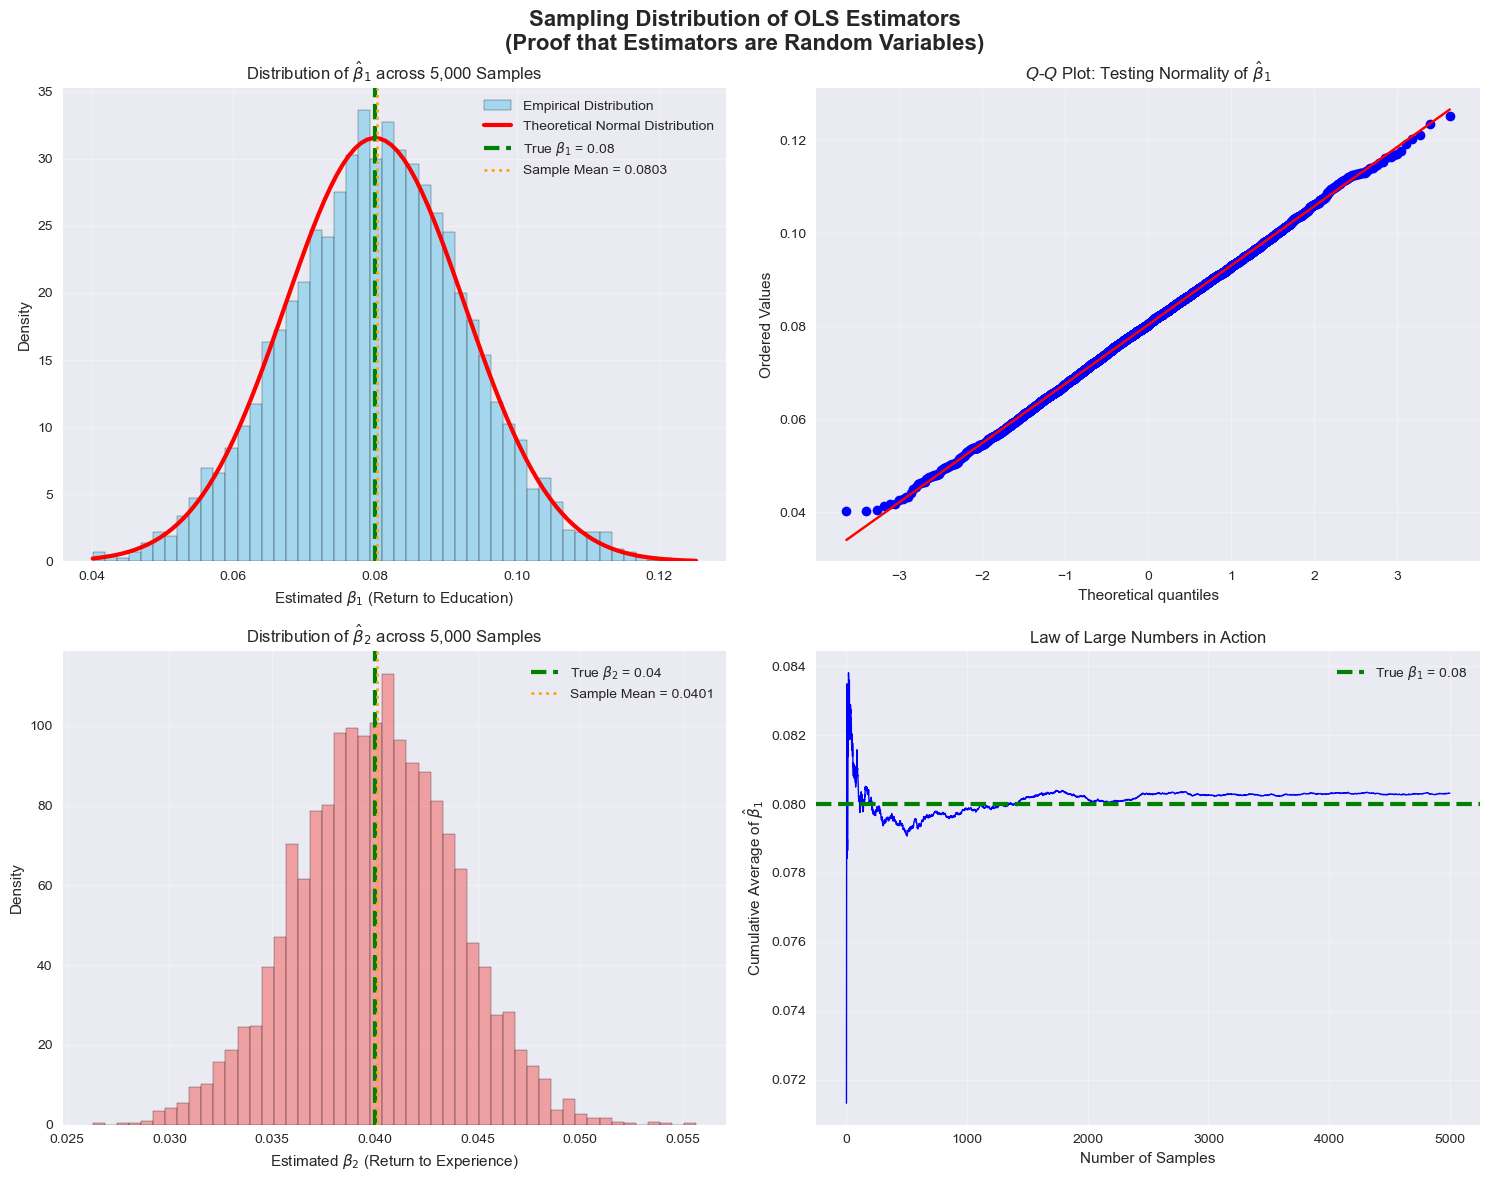

In [32]:
# =============================== #
#         Visualization
# =============================== #

print(f"\n6. VISUALIZING THE SAMPLING DISTRIBUTION")
print("-" * 40)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Sampling Distribution of OLS Estimators\n(Proof that Estimators are Random Variables)', 
             fontsize=16, fontweight='bold')

# Plot 1: Histogram of β₁ estimates
axes[0,0].hist(simulation_results['beta_1'], bins=50, density=True, alpha=0.7, 
               color='skyblue', edgecolor='black', label='Empirical Distribution')

# Overlay theoretical normal distribution
x_range = np.linspace(simulation_results['beta_1'].min(), 
                     simulation_results['beta_1'].max(), 100)
theoretical_density = stats.norm.pdf(x_range, TRUE_BETA_1, theoretical_std_beta1)
axes[0,0].plot(x_range, theoretical_density, 'r-', linewidth=3, 
               label='Theoretical Normal Distribution')

# Mark the true value
axes[0,0].axvline(TRUE_BETA_1, color='green', linewidth=3, linestyle='--', 
                  label=rf'True $\beta_1$ = {TRUE_BETA_1}')
axes[0,0].axvline(empirical_mean_beta1, color='orange', linewidth=2, linestyle=':', 
                  label=f'Sample Mean = {empirical_mean_beta1:.4f}')

axes[0,0].set_xlabel(r'Estimated $\beta_1$ (Return to Education)')
axes[0,0].set_ylabel('Density')
axes[0,0].set_title(
    rf'Distribution of $\hat{{\beta}}_1$ across {NUM_SAMPLES:,} Samples'
)

axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Q-Q plot to test normality
stats.probplot(simulation_results['beta_1'], dist="norm", plot=axes[0,1])
axes[0,1].set_title(r'$Q$-$Q$ Plot: Testing Normality of $\hat{\beta}_1$')
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Distribution of β₂ estimates
axes[1,0].hist(simulation_results['beta_2'], bins=50, density=True, alpha=0.7, 
               color='lightcoral', edgecolor='black')
axes[1,0].axvline(TRUE_BETA_2, color='green', linewidth=3, linestyle='--', 
                  label=rf'True $\beta_2$ = {TRUE_BETA_2}')
axes[1,0].axvline(simulation_results['beta_2'].mean(), color='orange', linewidth=2, 
                  linestyle=':', label=f'Sample Mean = {simulation_results["beta_2"].mean():.4f}')
axes[1,0].set_xlabel(r'Estimated $\beta_2$ (Return to Experience)')
axes[1,0].set_ylabel('Density')
axes[1,0].set_title(
    rf'Distribution of $\hat{{\beta}}_2$ across {NUM_SAMPLES:,} Samples'
)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Convergence of sample mean to true value
cumulative_means = simulation_results['beta_1'].expanding().mean()
axes[1,1].plot(range(1, len(cumulative_means) + 1), cumulative_means, 
               color='blue', linewidth=1)
axes[1,1].axhline(TRUE_BETA_1, color='green', linewidth=3, linestyle='--', 
                  label=rf'True $\beta_1$ = {TRUE_BETA_1}')
axes[1,1].set_xlabel('Number of Samples')
axes[1,1].set_ylabel(r'Cumulative Average of $\hat{\beta}_1$')
axes[1,1].set_title('Law of Large Numbers in Action')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
# =============================== #
#      Statistical Tests
# =============================== #

print(f"\n7. STATISTICAL VERIFICATION")
print("-" * 40)

# Test 1: Is the empirical mean close to the true value? (Unbiasedness)
t_stat_unbiased = (empirical_mean_beta1 - TRUE_BETA_1) / (empirical_std_beta1 / np.sqrt(NUM_SAMPLES))
p_value_unbiased = 2 * (1 - stats.t.cdf(abs(t_stat_unbiased), NUM_SAMPLES - 1))

print(f"TEST 1: Unbiasedness of β̂₁")
print(f"  H₀: E[β̂₁] = β₁ = {TRUE_BETA_1}")
print(f"  t-statistic: {t_stat_unbiased:.4f}")
print(f"  p-value: {p_value_unbiased:.4f}")
print(f"  Result: {'PASS' if p_value_unbiased > 0.05 else 'FAIL'} - Estimator is unbiased")

# Test 2: Normality test
shapiro_stat, shapiro_p = stats.shapiro(simulation_results['beta_1'][:5000])  # Shapiro-Wilk test
print(f"\nTEST 2: Normality of β̂₁ distribution")
print(f"  H₀: β̂₁ follows normal distribution")
print(f"  Shapiro-Wilk statistic: {shapiro_stat:.4f}")
print(f"  p-value: {shapiro_p:.4f}")
print(f"  Result: {'PASS' if shapiro_p > 0.05 else 'FAIL'} - Distribution is normal")

# Test 3: Variance comparison
var_ratio = empirical_std_beta1**2 / theoretical_var_beta1
print(f"\nTEST 3: Variance comparison")
print(f"  Empirical variance: {empirical_std_beta1**2:.6f}")
print(f"  Theoretical variance: {theoretical_var_beta1:.6f}")
print(f"  Ratio (should be ≈ 1): {var_ratio:.4f}")
print(f"  Result: {'PASS' if 0.95 <= var_ratio <= 1.05 else 'FAIL'} - Variances match theory")


7. STATISTICAL VERIFICATION
----------------------------------------
TEST 1: Unbiasedness of β̂₁
  H₀: E[β̂₁] = β₁ = 0.08
  t-statistic: 1.7469
  p-value: 0.0807
  Result: PASS - Estimator is unbiased

TEST 2: Normality of β̂₁ distribution
  H₀: β̂₁ follows normal distribution
  Shapiro-Wilk statistic: 0.9995
  p-value: 0.2593
  Result: PASS - Distribution is normal

TEST 3: Variance comparison
  Empirical variance: 0.000162
  Theoretical variance: 0.000160
  Ratio (should be ≈ 1): 1.0136
  Result: PASS - Variances match theory


In [37]:
# =============================== #
#      Summary and Insights
# =============================== #

print(f"\n8. KEY INSIGHTS FROM THIS SIMULATION")
print("=" * 50)

print(f"✓ TRUE PARAMETERS ARE FIXED:")
print(f"  β₁ = {TRUE_BETA_1} (this never changes - it's a constant in the population)")

print(f"\n✓ ESTIMATORS ARE RANDOM VARIABLES:")
print(f"  Our {NUM_SAMPLES:,} estimates of β₁ ranged from {simulation_results['beta_1'].min():.4f} to {simulation_results['beta_1'].max():.4f}")
print(f"  Each estimate came from a different random sample")

print(f"\n✓ SAMPLING DISTRIBUTION EXISTS:")
print(f"  The histogram shows how β̂₁ varies across all possible samples")
print(f"  This distribution is approximately normal (as theory predicts)")
print(f"  It's centered at the true value (unbiased)")

print(f"\n✓ THEORY MATCHES PRACTICE:")
print(f"  Theoretical standard error: {theoretical_std_beta1:.4f}")
print(f"  Empirical standard error: {empirical_std_beta1:.4f}")
print(f"  The difference is only {abs(theoretical_std_beta1 - empirical_std_beta1):.4f}!")

print(f"\n✓ WHY THIS MATTERS FOR INFERENCE:")
print(f"  When we get β̂₁ = {one_sample_result['beta_1']:.4f} from our one sample,")
print(f"  we know it came from a normal distribution centered at the true value")
print(f"  This allows us to calculate confidence intervals and do hypothesis tests!")

print(f"\n" + "=" * 50)
print(f"CONCLUSION: This simulation proves that OLS estimators are random")
print(f"variables with known sampling distributions, enabling statistical inference!")
print(f"=" * 50)


8. KEY INSIGHTS FROM THIS SIMULATION
✓ TRUE PARAMETERS ARE FIXED:
  β₁ = 0.08 (this never changes - it's a constant in the population)

✓ ESTIMATORS ARE RANDOM VARIABLES:
  Our 5,000 estimates of β₁ ranged from 0.0402 to 0.1253
  Each estimate came from a different random sample

✓ SAMPLING DISTRIBUTION EXISTS:
  The histogram shows how β̂₁ varies across all possible samples
  This distribution is approximately normal (as theory predicts)
  It's centered at the true value (unbiased)

✓ THEORY MATCHES PRACTICE:
  Theoretical standard error: 0.0126
  Empirical standard error: 0.0127
  The difference is only 0.0001!

✓ WHY THIS MATTERS FOR INFERENCE:
  When we get β̂₁ = 0.0811 from our one sample,
  we know it came from a normal distribution centered at the true value
  This allows us to calculate confidence intervals and do hypothesis tests!

CONCLUSION: This simulation proves that OLS estimators are random
variables with known sampling distributions, enabling statistical inference!
